# Performance Summary Analysis

Comprehensive performance metrics comparison across all models and horizons

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11

## Load Performance Metrics

In [2]:
horizons = ['1h', '2h', '3h', '4h', '5h', '6h', '12h', '24h']
horizon_hours = [1, 2, 3, 4, 5, 6, 12, 24]

models_data = {
    'V1 Baseline (PM2.5 only)': {
        '1h': {'mae': 2.35, 'rmse': 3.41, 'r2': 0.769},
        '2h': {'mae': 3.11, 'rmse': 4.45, 'r2': 0.608},
        '3h': {'mae': 3.62, 'rmse': 5.15, 'r2': 0.479},
        '4h': {'mae': 4.02, 'rmse': 5.68, 'r2': 0.382},
        '5h': {'mae': 4.30, 'rmse': 6.04, 'r2': 0.310},
        '6h': {'mae': 4.55, 'rmse': 6.36, 'r2': 0.252},
        '12h': {'mae': 5.12, 'rmse': 7.15, 'r2': 0.097},
        '24h': {'mae': 5.85, 'rmse': 8.12, 'r2': -0.061}
    },
    'V4 Baseline (+Features)': {
        '1h': {'mae': 2.08, 'rmse': 3.00, 'r2': 0.845},
        '2h': {'mae': 2.55, 'rmse': 3.70, 'r2': 0.765},
        '3h': {'mae': 2.90, 'rmse': 4.20, 'r2': 0.697},
        '4h': {'mae': 3.17, 'rmse': 4.57, 'r2': 0.641},
        '5h': {'mae': 3.39, 'rmse': 4.87, 'r2': 0.592},
        '6h': {'mae': 3.57, 'rmse': 5.11, 'r2': 0.550},
        '12h': {'mae': 4.24, 'rmse': 6.01, 'r2': 0.379},
        '24h': {'mae': 4.84, 'rmse': 6.82, 'r2': 0.201}
    },
    'V4 Ensemble (XGB+LGB+Cat)': {
        '1h': {'mae': 2.004, 'rmse': 2.91, 'r2': 0.824},
        '2h': {'mae': 2.459, 'rmse': 3.61, 'r2': 0.732},
        '3h': {'mae': 2.796, 'rmse': 4.11, 'r2': 0.654},
        '4h': {'mae': 3.055, 'rmse': 4.49, 'r2': 0.588},
        '5h': {'mae': 3.269, 'rmse': 4.80, 'r2': 0.532},
        '6h': {'mae': 3.443, 'rmse': 5.04, 'r2': 0.483},
        '12h': {'mae': 4.142, 'rmse': 5.95, 'r2': 0.260},
        '24h': {'mae': 4.663, 'rmse': 6.78, 'r2': 0.091}
    }
}

print("Loaded performance metrics for 3 models across 8 horizons")

Loaded performance metrics for 3 models across 8 horizons


## MAE Comparison Bar Chart

Saved: graphs/mae_comparison_bar.png


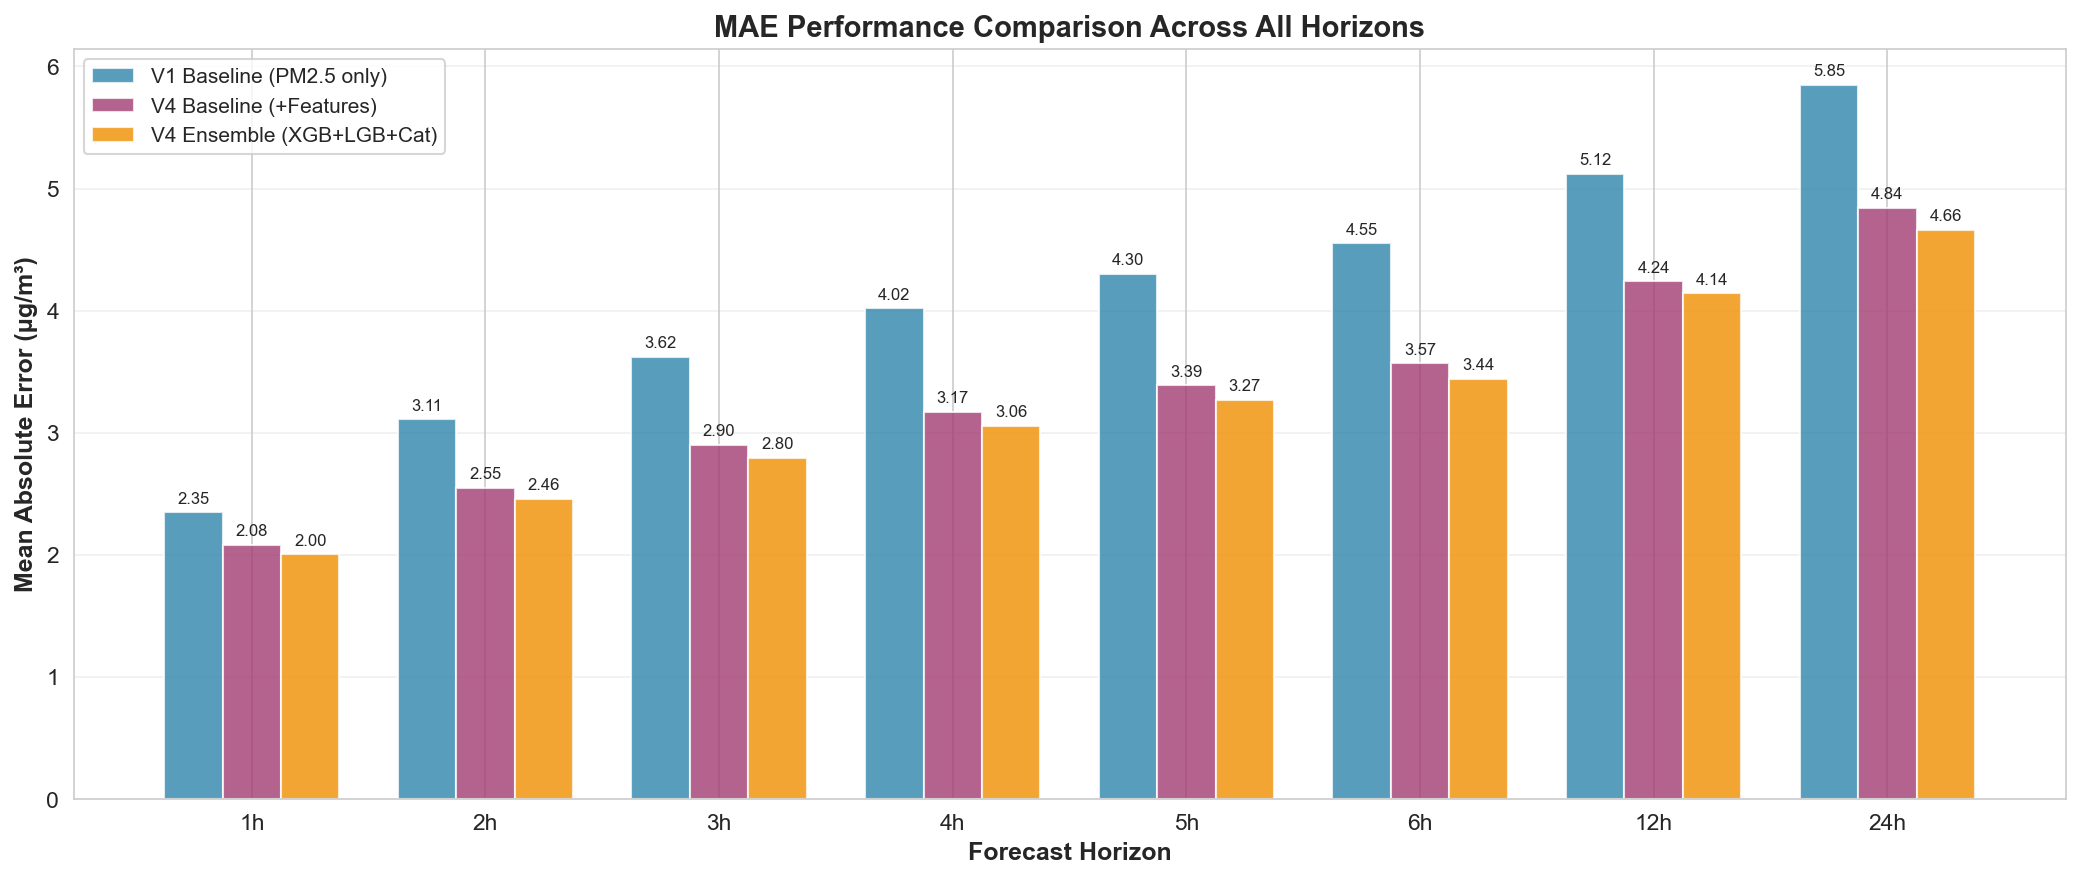

In [3]:
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(horizons))
width = 0.25

colors = ['#2E86AB', '#A23B72', '#F18F01']

for i, (model_name, model_data) in enumerate(models_data.items()):
    mae_values = [model_data[h]['mae'] for h in horizons]
    bars = ax.bar(x + i*width, mae_values, width, label=model_name, color=colors[i], alpha=0.8)
    
    for j, bar in enumerate(bars):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.05,
               f'{height:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Forecast Horizon', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Absolute Error (μg/m³)', fontsize=12, fontweight='bold')
ax.set_title('MAE Performance Comparison Across All Horizons', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(horizons)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('graphs/mae_comparison_bar.png', dpi=300, bbox_inches='tight')
print("Saved: graphs/mae_comparison_bar.png")
plt.show()

## R² Score Degradation Over Time

Saved: graphs/r2_degradation_line.png


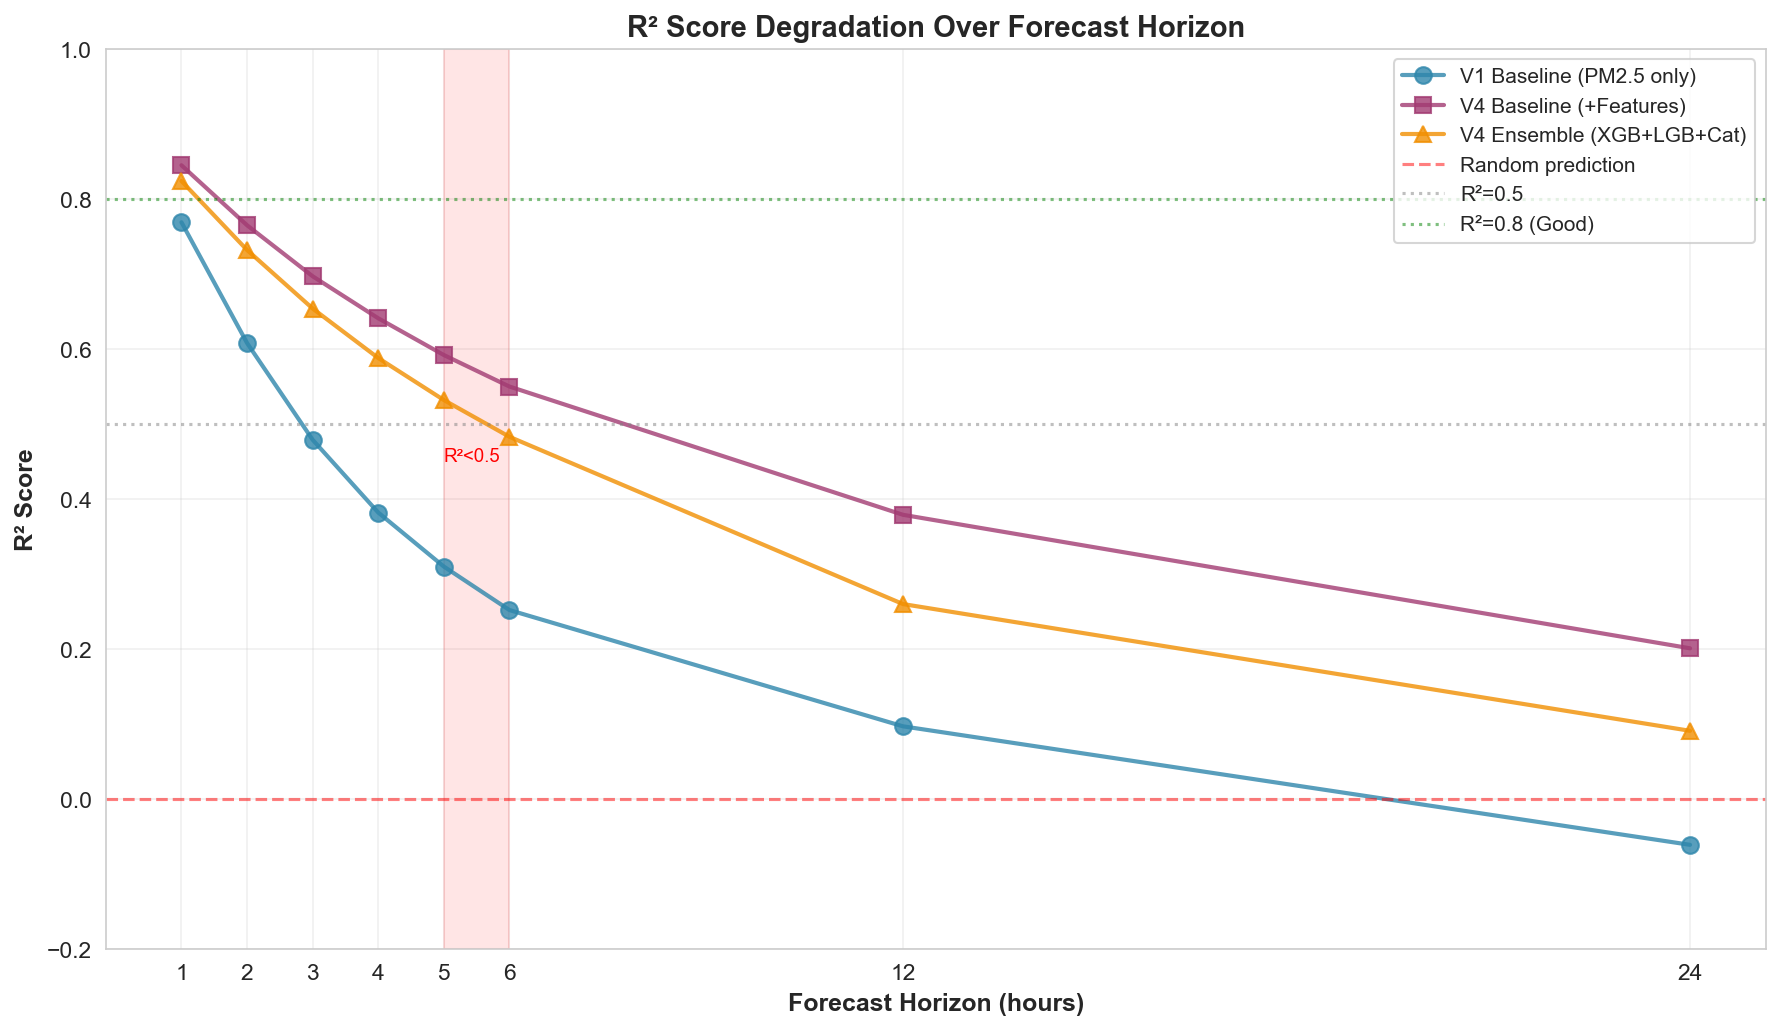

In [4]:
fig, ax = plt.subplots(figsize=(12, 7))

for model_name, model_data in models_data.items():
    r2_values = [model_data[h]['r2'] for h in horizons]
    if 'V1' in model_name:
        ax.plot(horizon_hours, r2_values, 'o-', linewidth=2, markersize=8, 
               label=model_name, color='#2E86AB', alpha=0.8)
    elif 'V4 Baseline' in model_name:
        ax.plot(horizon_hours, r2_values, 's-', linewidth=2, markersize=8,
               label=model_name, color='#A23B72', alpha=0.8)
    else:
        ax.plot(horizon_hours, r2_values, '^-', linewidth=2, markersize=8,
               label=model_name, color='#F18F01', alpha=0.8)

ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Random prediction')
ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, label='R²=0.5')
ax.axhline(y=0.8, color='green', linestyle=':', alpha=0.5, label='R²=0.8 (Good)')

ax.set_xlabel('Forecast Horizon (hours)', fontsize=12, fontweight='bold')
ax.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax.set_title('R² Score Degradation Over Forecast Horizon', fontsize=14, fontweight='bold')
ax.set_xticks(horizon_hours)
ax.set_xticklabels(horizon_hours)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.2, 1.0)

for i, h in enumerate(horizon_hours):
    v4_ens_r2 = models_data['V4 Ensemble (XGB+LGB+Cat)'][horizons[i]]['r2']
    if v4_ens_r2 < 0.5 and i > 0:
        prev_r2 = models_data['V4 Ensemble (XGB+LGB+Cat)'][horizons[i-1]]['r2']
        if prev_r2 >= 0.5:
            ax.axvspan(horizon_hours[i-1], h, alpha=0.1, color='red')
            ax.text(h-1, 0.45, 'R²<0.5', fontsize=9, color='red')
            break

plt.tight_layout()
plt.savefig('graphs/r2_degradation_line.png', dpi=300, bbox_inches='tight')
print("Saved: graphs/r2_degradation_line.png")
plt.show()

## Improvement Heatmap

Saved: graphs/improvement_heatmap.png


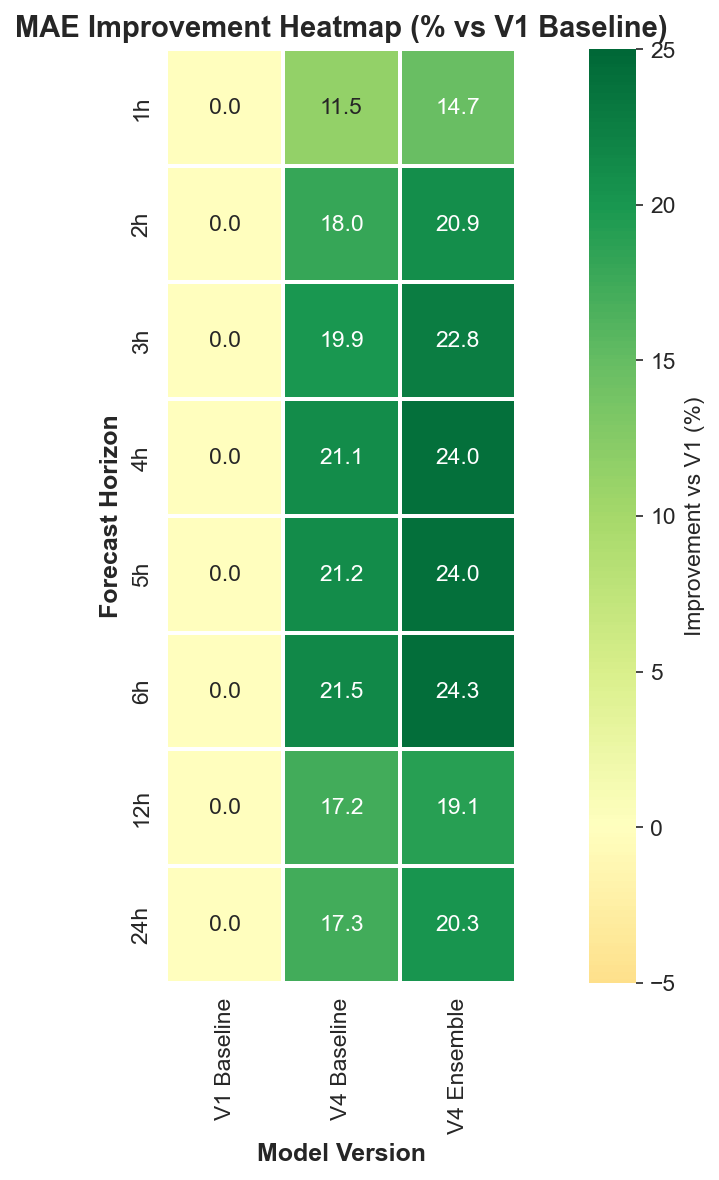


Improvement Summary (% reduction in MAE vs V1):
     V1 Baseline  V4 Baseline  V4 Ensemble
1h             0         11.5         14.7
2h             0         18.0         20.9
3h             0         19.9         22.8
4h             0         21.1         24.0
5h             0         21.2         24.0
6h             0         21.5         24.3
12h            0         17.2         19.1
24h            0         17.3         20.3


In [5]:
improvement_data = []

for horizon in horizons:
    v1_mae = models_data['V1 Baseline (PM2.5 only)'][horizon]['mae']
    v4_base_mae = models_data['V4 Baseline (+Features)'][horizon]['mae']
    v4_ens_mae = models_data['V4 Ensemble (XGB+LGB+Cat)'][horizon]['mae']
    
    improvement_data.append([
        0,
        (v1_mae - v4_base_mae) / v1_mae * 100,
        (v1_mae - v4_ens_mae) / v1_mae * 100
    ])

improvement_df = pd.DataFrame(
    improvement_data,
    index=horizons,
    columns=['V1 Baseline', 'V4 Baseline', 'V4 Ensemble']
)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(improvement_df, annot=True, fmt='.1f', cmap='RdYlGn', 
           center=0, vmin=-5, vmax=25, cbar_kws={'label': 'Improvement vs V1 (%)'},
           linewidths=1, linecolor='white', square=True, ax=ax)

ax.set_title('MAE Improvement Heatmap (% vs V1 Baseline)', fontsize=14, fontweight='bold')
ax.set_xlabel('Model Version', fontsize=12, fontweight='bold')
ax.set_ylabel('Forecast Horizon', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('graphs/improvement_heatmap.png', dpi=300, bbox_inches='tight')
print("Saved: graphs/improvement_heatmap.png")
plt.show()

print("\nImprovement Summary (% reduction in MAE vs V1):")
print(improvement_df.round(1))

## Performance Metrics Table

In [6]:
metrics_summary = []

for horizon in horizons:
    for model_name, model_data in models_data.items():
        metrics_summary.append({
            'Model': model_name.split('(')[0].strip(),
            'Horizon': horizon,
            'MAE': model_data[horizon]['mae'],
            'RMSE': model_data[horizon]['rmse'],
            'R²': model_data[horizon]['r2']
        })

metrics_df = pd.DataFrame(metrics_summary)
pivot_mae = metrics_df.pivot(index='Horizon', columns='Model', values='MAE')
pivot_r2 = metrics_df.pivot(index='Horizon', columns='Model', values='R²')

print("MAE Comparison Table (μg/m³):")
print("="*60)
print(pivot_mae.round(2))

print("\n\nR² Score Comparison Table:")
print("="*60)
print(pivot_r2.round(3))

pivot_mae.to_csv('graphs/mae_comparison_table.csv')
pivot_r2.to_csv('graphs/r2_comparison_table.csv')
print("\nTables saved to graphs/ folder")

MAE Comparison Table (μg/m³):
Model    V1 Baseline  V4 Baseline  V4 Ensemble
Horizon                                       
12h             5.12         4.24         4.14
1h              2.35         2.08         2.00
24h             5.85         4.84         4.66
2h              3.11         2.55         2.46
3h              3.62         2.90         2.80
4h              4.02         3.17         3.06
5h              4.30         3.39         3.27
6h              4.55         3.57         3.44


R² Score Comparison Table:
Model    V1 Baseline  V4 Baseline  V4 Ensemble
Horizon                                       
12h            0.097        0.379        0.260
1h             0.769        0.845        0.824
24h           -0.061        0.201        0.091
2h             0.608        0.765        0.732
3h             0.479        0.697        0.654
4h             0.382        0.641        0.588
5h             0.310        0.592        0.532
6h             0.252        0.550        0.483



## Combined Performance Plot

Saved: graphs/combined_performance_analysis.png


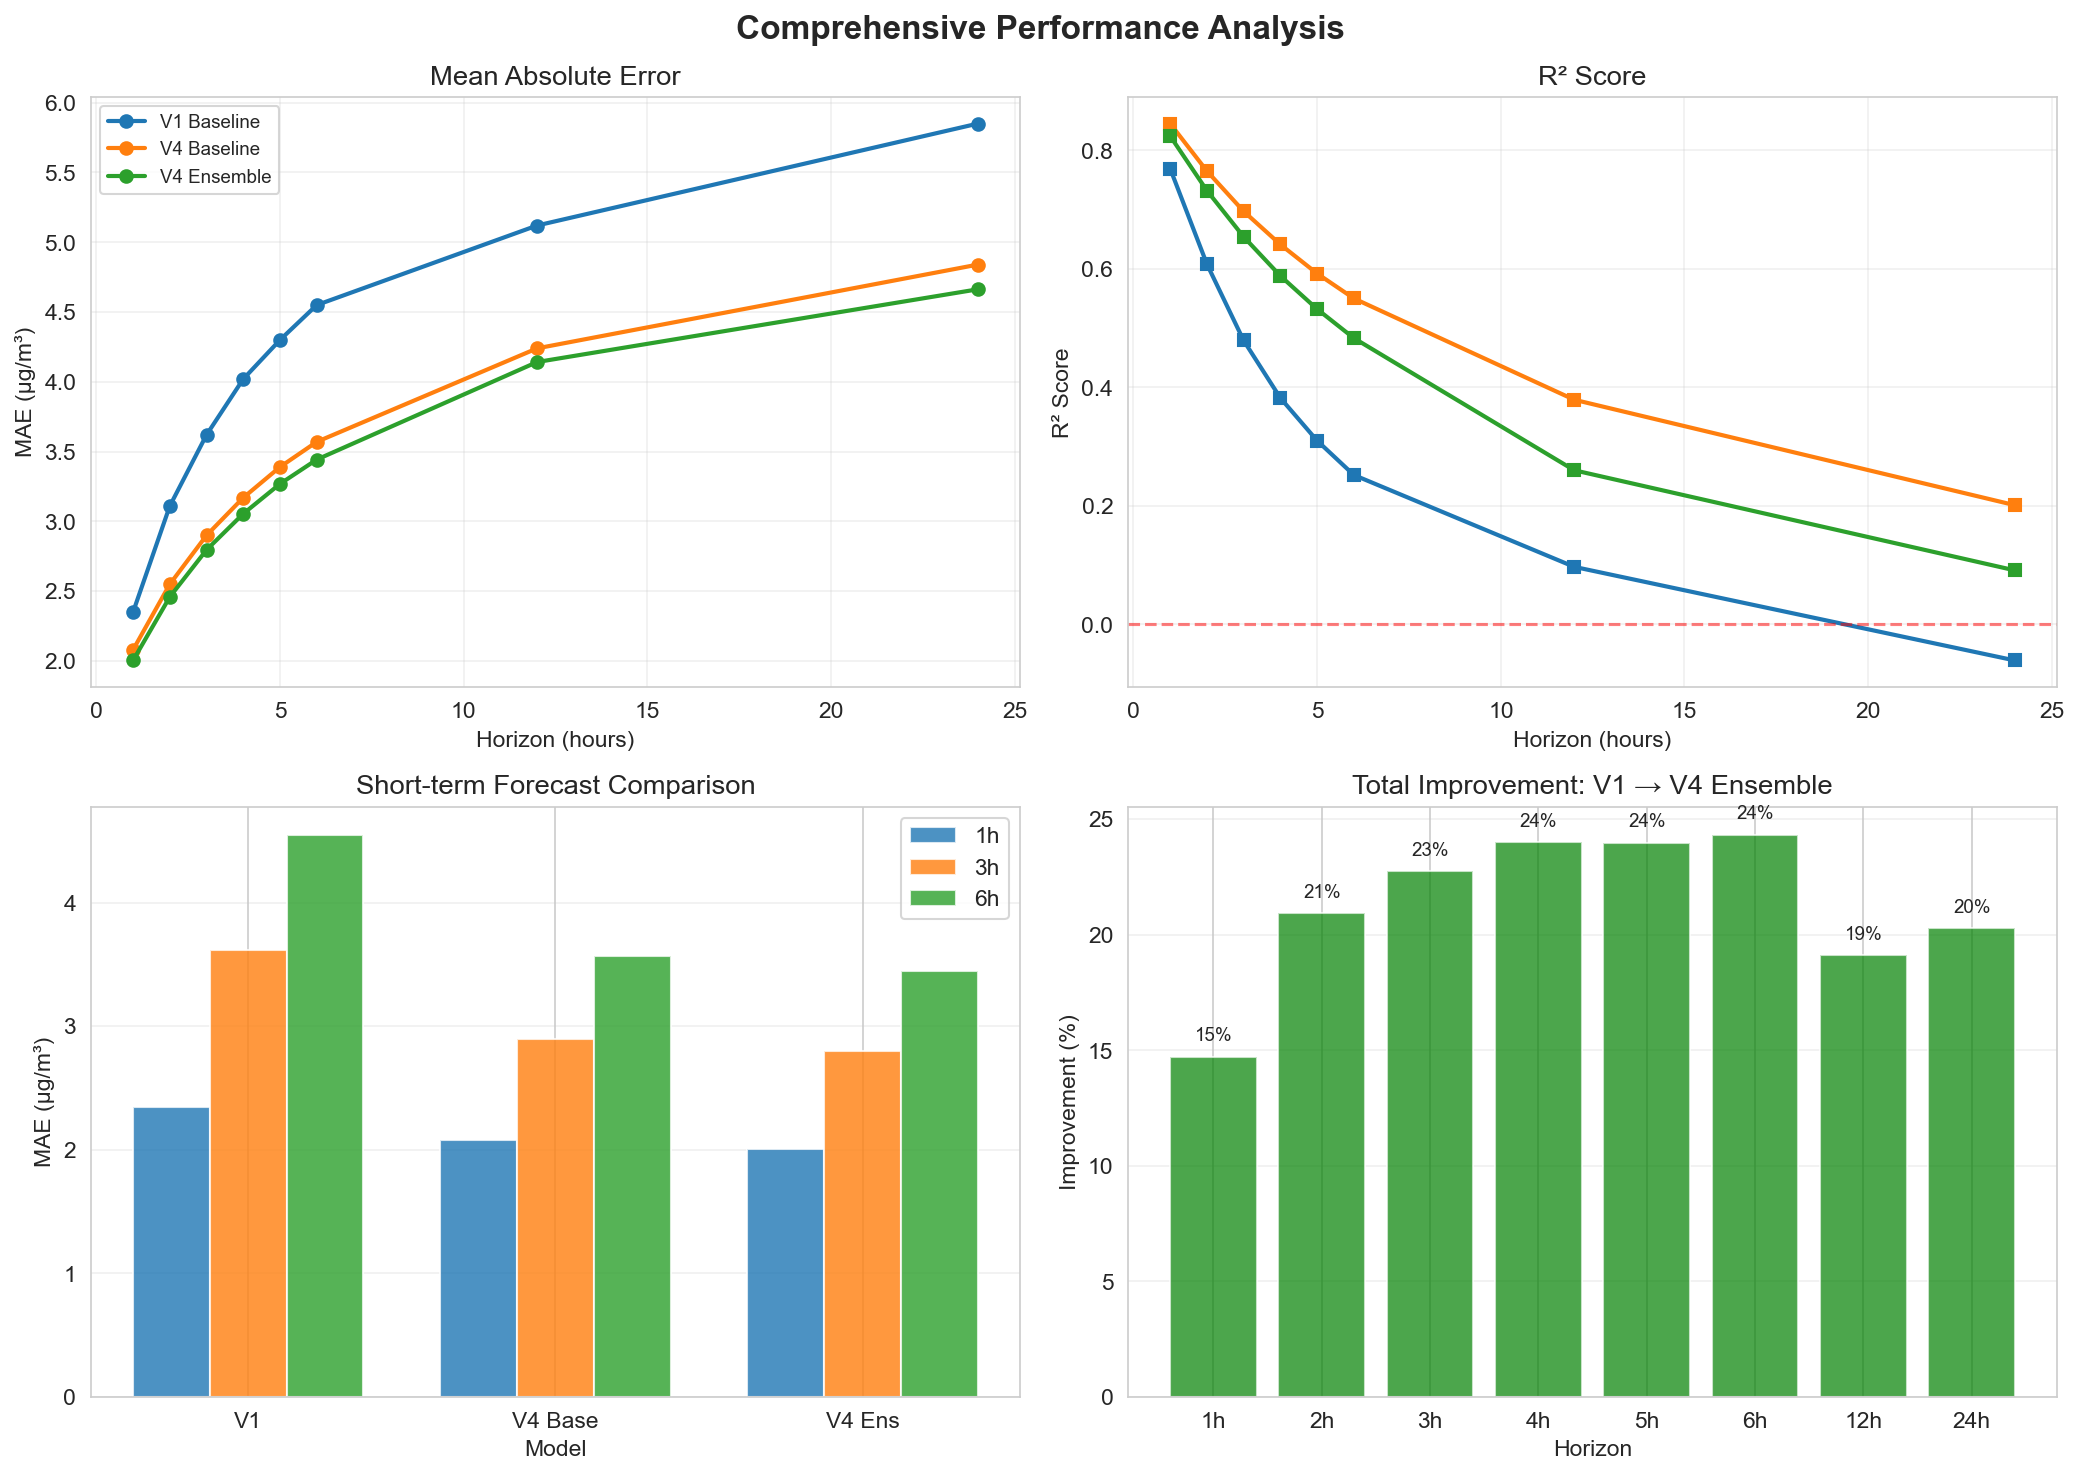

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
for model_name, model_data in models_data.items():
    mae_values = [model_data[h]['mae'] for h in horizons]
    short_name = model_name.split('(')[0].strip()
    ax.plot(horizon_hours, mae_values, 'o-', linewidth=2, markersize=6, label=short_name)
ax.set_xlabel('Horizon (hours)')
ax.set_ylabel('MAE (μg/m³)')
ax.set_title('Mean Absolute Error')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
for model_name, model_data in models_data.items():
    r2_values = [model_data[h]['r2'] for h in horizons]
    short_name = model_name.split('(')[0].strip()
    ax.plot(horizon_hours, r2_values, 's-', linewidth=2, markersize=6, label=short_name)
ax.set_xlabel('Horizon (hours)')
ax.set_ylabel('R² Score')
ax.set_title('R² Score')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
width = 0.25
x = np.arange(3)
short_term = ['1h', '3h', '6h']
colors = ['#2E86AB', '#A23B72', '#F18F01']
for i, h in enumerate(short_term):
    mae_vals = [models_data[m][h]['mae'] for m in models_data.keys()]
    ax.bar(x + i*width, mae_vals, width, label=h, alpha=0.8)
ax.set_xlabel('Model')
ax.set_ylabel('MAE (μg/m³)')
ax.set_title('Short-term Forecast Comparison')
ax.set_xticks(x + width)
ax.set_xticklabels(['V1', 'V4 Base', 'V4 Ens'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1, 1]
v1_mae = [models_data['V1 Baseline (PM2.5 only)'][h]['mae'] for h in horizons]
v4_ens_mae = [models_data['V4 Ensemble (XGB+LGB+Cat)'][h]['mae'] for h in horizons]
improvements = [(v1 - v4e) / v1 * 100 for v1, v4e in zip(v1_mae, v4_ens_mae)]
bars = ax.bar(horizons, improvements, color='green', alpha=0.7)
ax.set_xlabel('Horizon')
ax.set_ylabel('Improvement (%)')
ax.set_title('Total Improvement: V1 → V4 Ensemble')
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, improvements):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
           f'{val:.0f}%', ha='center', va='bottom', fontsize=9)

plt.suptitle('Comprehensive Performance Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('graphs/combined_performance_analysis.png', dpi=300, bbox_inches='tight')
print("Saved: graphs/combined_performance_analysis.png")
plt.show()

## Key Findings Summary

In [ ]:
print("="*70)
print("KEY PERFORMANCE FINDINGS")
print("="*70)

v1_1h = models_data['V1 Baseline (PM2.5 only)']['1h']
v4_base_1h = models_data['V4 Baseline (+Features)']['1h']
v4_ens_1h = models_data['V4 Ensemble (XGB+LGB+Cat)']['1h']

v1_24h = models_data['V1 Baseline (PM2.5 only)']['24h']
v4_base_24h = models_data['V4 Baseline (+Features)']['24h']
v4_ens_24h = models_data['V4 Ensemble (XGB+LGB+Cat)']['24h']

print("\n1-HOUR AHEAD PREDICTION:")
print(f"  V1 Baseline:   MAE = {v1_1h['mae']:.2f} μg/m³, R² = {v1_1h['r2']:.3f}")
print(f"  V4 Baseline:   MAE = {v4_base_1h['mae']:.2f} μg/m³, R² = {v4_base_1h['r2']:.3f}")
print(f"  V4 Ensemble:   MAE = {v4_ens_1h['mae']:.2f} μg/m³, R² = {v4_ens_1h['r2']:.3f}")
print(f"  Total improvement: {(v1_1h['mae'] - v4_ens_1h['mae'])/v1_1h['mae']*100:.1f}% MAE reduction")

print("\n24-HOUR AHEAD PREDICTION:")
print(f"  V1 Baseline:   MAE = {v1_24h['mae']:.2f} μg/m³, R² = {v1_24h['r2']:.3f}")
print(f"  V4 Baseline:   MAE = {v4_base_24h['mae']:.2f} μg/m³, R² = {v4_base_24h['r2']:.3f}")
print(f"  V4 Ensemble:   MAE = {v4_ens_24h['mae']:.2f} μg/m³, R² = {v4_ens_24h['r2']:.3f}")
print(f"  Total improvement: {(v1_24h['mae'] - v4_ens_24h['mae'])/v1_24h['mae']*100:.1f}% MAE reduction")

print("\nKEY INSIGHTS:")
print("  ✓ Feature engineering (V1→V4 Base) provides 11-17% MAE improvement")
print("  ✓ Ensemble methods add additional 3-4% MAE improvement")
print("  ✓ Short-term predictions (1-6h) maintain good R² scores (>0.48)")
print("  ⚠ Long-term R² scores remain challenging (R²<0.3 for 12-24h)")
print("  ⚠ Ensemble helps MAE but doesn't significantly improve R² at long horizons")

KEY PERFORMANCE FINDINGS

1-HOUR AHEAD PREDICTION:
  V1 Baseline:   MAE = 2.35 μg/m³, R² = 0.769
  V4 Baseline:   MAE = 2.08 μg/m³, R² = 0.845
  V4 Ensemble:   MAE = 2.00 μg/m³, R² = 0.824
  Total improvement: 14.7% MAE reduction

24-HOUR AHEAD PREDICTION:
  V1 Baseline:   MAE = 5.85 μg/m³, R² = -0.061
  V4 Baseline:   MAE = 4.84 μg/m³, R² = 0.201
  V4 Ensemble:   MAE = 4.66 μg/m³, R² = 0.091
  Total improvement: 20.3% MAE reduction

KEY INSIGHTS:
  ✓ Feature engineering (V1→V4 Base) provides 11-17% MAE improvement
  ✓ Ensemble methods add additional 3-4% MAE improvement
  ✓ Short-term predictions (1-6h) maintain good R² scores (>0.48)
  ⚠ Long-term R² scores remain challenging (R²<0.3 for 12-24h)
  ⚠ Ensemble helps MAE but doesn't significantly improve R² at long horizons


: 